# Document Alignment

## **Mohammad Amanlou - Mohammad Amin Yousefi - Mobina Mehrazar**

## Description
In this project we implement a system for aligning a scanned document to a reference template using computer vision techniques. The alignment is achieved through feature matching, homography estimation, and image warping. The system outputs intermediary steps, including keypoints, matched features, and the final aligned image.

## Requirements
- **Libraries**: OpenCV, NumPy, Matplotlib, OS
- **File Structure**:
  - Input images stored in `images/`
  - Output images stored in `outputImages/`

## Outputs
### Expected Outputs
1. **Images**:
   - Original and scanned images.
   - Keypoints detected in both images.
   - Matched keypoints visualization.
   - Final aligned image.

### Sample Outputs
The processed images, including visualizations of the detected keypoints, matched keypoints, and the aligned image, are saved in the `outputImages/` directory.

## Algorithm Details

1. **Load Images**
    - Read the reference template (`form.jpg`) and the scanned document (`scanned-form.jpg`) using OpenCV.
    - Convert both images from BGR to RGB color format for visualization.

2. **Detect Keypoints**
    - Convert the images to grayscale to simplify feature extraction.
    - Use the ORB (Oriented FAST and Rotated BRIEF) algorithm to detect keypoints in each image and compute their descriptors.

3. **Match Keypoints**
    - Use the `BruteForce-Hamming` descriptor matcher to match the feature descriptors between the two images.
    - Sort the matches by distance and retain the top 10% of matches for accuracy.
    - Visualize the matched keypoints.

4. **Estimate Homography**
    - Extract the coordinates of the matched keypoints in both images.
    - Compute the homography matrix using the RANSAC algorithm to handle outliers.

5. **Warp Image**
    - Use the computed homography matrix to warp the scanned image, aligning it to the reference template.
    - Save the aligned image for further processing.

In [1]:
# Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Read Tempalate and Scanned Image

In [2]:
def display_images_from_dict(images_dict, num_columns=3, size=5):
    titles = list(images_dict.keys())
    images = list(images_dict.values())
    num_rows = (len(images) + num_columns - 1) // num_columns 

    plt.figure(figsize=(size * num_columns, size * num_rows))

    for index, (title, image) in enumerate(zip(titles, images)):
        plt.subplot(num_rows, num_columns, index + 1)
        cmap = 'gray' if len(image.shape) == 2 else None
        plt.imshow(image, cmap=cmap)

        plt.title(title, fontsize=8)
        plt.axis('off')

    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    plt.tight_layout(pad=0.1)
    plt.show()


In [3]:
OUTPUT_FOLDER = "outputImages"
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

In [4]:
# Define the path to the reference image file using os.path.join for cross-platform compatibility
refFilename = os.path.join("images", "form.jpg")

# Read the reference image in color mode
im1 = cv2.imread(refFilename)

# Convert the reference image from BGR to RGB format
im1 = cv2.cvtColor(im1, cv2.COLOR_BGR2RGB)

# Define the path to the image to be aligned using os.path.join for cross-platform compatibility
imFilename = os.path.join("images", "scanned-form.jpg")

# Read the image to be aligned in color mode
im2  = cv2.imread(imFilename)

# Convert the image to be aligned from BGR to RGB format
im2 = cv2.cvtColor(im2, cv2.COLOR_BGR2RGB)

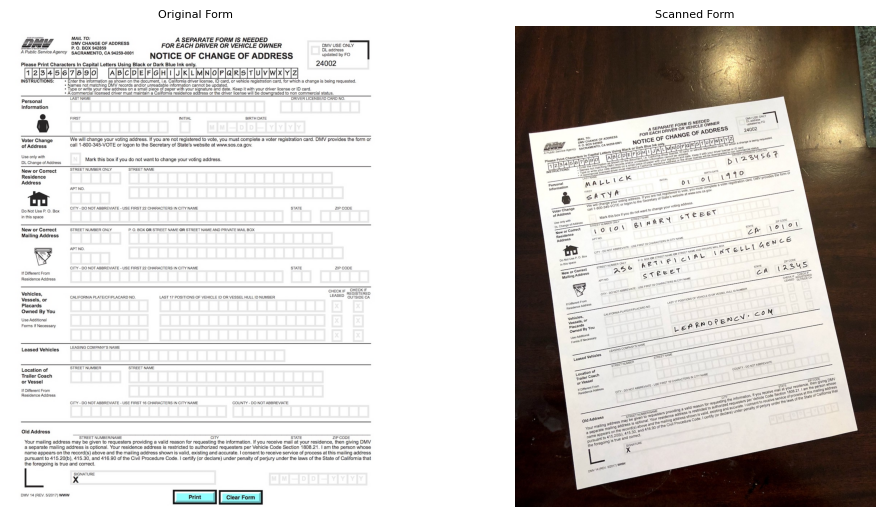

In [5]:
# Display Images
images_dict = {
    "Original Form": im1,
    "Scanned Form": im2,
}

display_images_from_dict(images_dict)

## Step 2: Find keypoints in both Images

Think of keypoints as corner points that are stable under image transformations

In [6]:
# Convert images to grayscale
im1_gray = cv2.cvtColor(im1, cv2.COLOR_RGB2GRAY)
im2_gray = cv2.cvtColor(im2, cv2.COLOR_RGB2GRAY)


# Detect ORB features using OpenCV and compute descriptors.
MAX_NUM_FEATURES = 500
orb = cv2.ORB_create()
keypoints1, descriptors1 = orb.compute(im1, orb.detect(im1,None))
keypoints2, descriptors2 = orb.compute(im2, orb.detect(im2,None))

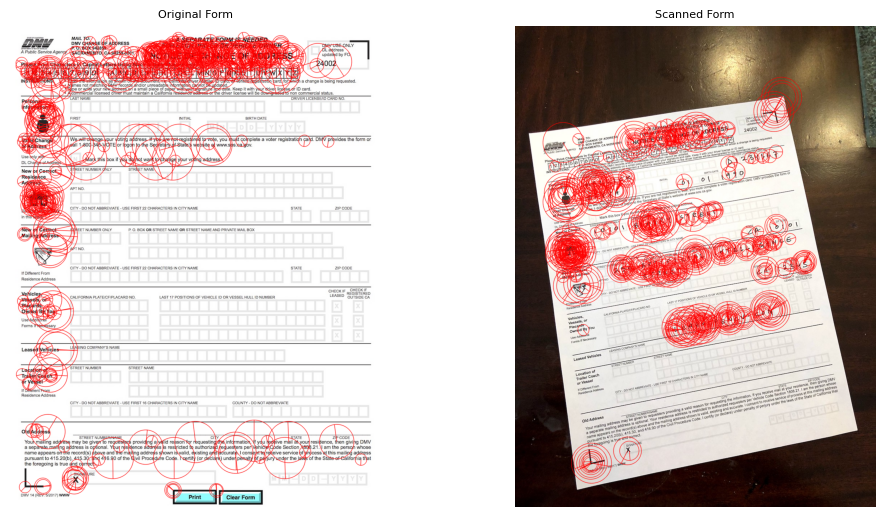

True

In [7]:
# Display
im1_display = cv2.drawKeypoints(
    im1,
    keypoints1,
    outImage=np.array([]),
    color=(255, 0, 0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)

im2_display = cv2.drawKeypoints(
    im2,
    keypoints2,
    outImage=np.array([]),
    color=(255, 0, 0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)

# Plot
images_dict = {
    "Original Form": im1_display,
    "Scanned Form": im2_display,
}

display_images_from_dict(images_dict)

cv2.imwrite(os.path.join(OUTPUT_FOLDER, "originalFormKP.jpg"), cv2.cvtColor(im1_display, cv2.COLOR_BGR2RGB))
cv2.imwrite(os.path.join(OUTPUT_FOLDER, "scannedFormKP.jpg"), cv2.cvtColor(im2_display, cv2.COLOR_BGR2RGB))

## Step 3 : Match keypoints in the two image

In [8]:
# Create a DescriptorMatcher object with the BRUTEFORCE_HAMMING algorithm.
# This matcher is used to compare feature descriptors and find the best matches.
matcher = cv2.DescriptorMatcher.create("BruteForce-Hamming")

# Match the feature descriptors from two images.
# The match() function finds the best matches between descriptors1 and descriptors2.
# The resulting matches are stored in a list.
matches = list(matcher.match(descriptors1, descriptors2, None))

# Sort the matches based on their distance.
# The distance represents how similar the matched descriptors are.
# Sorting in ascending order (reverse=False) means the best matches (lowest distance) come first.
matches.sort(key=lambda x: x.distance, reverse=False)

# Determine the number of good matches to keep.
# Here, we keep the top 10% of matches.
numGoodMatches = int(len(matches) * 0.1)

# Slice the sorted matches to keep only the top 'numGoodMatches'.
matches = matches[:numGoodMatches]


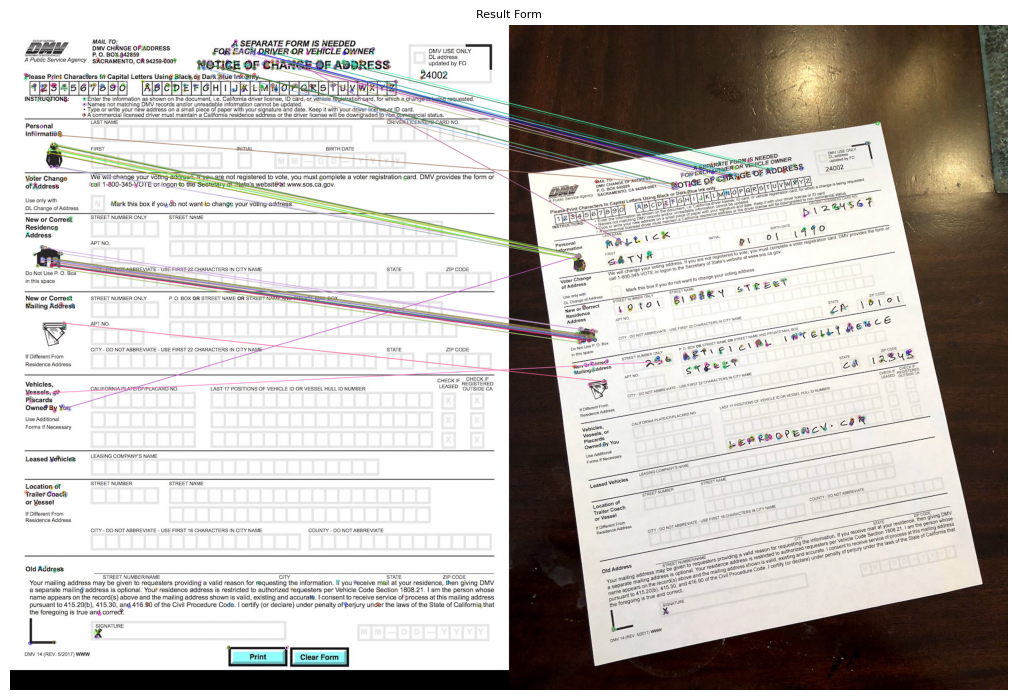

True

In [9]:
# Draw top matches
im_matches = cv2.drawMatches(im1, keypoints1, im2, keypoints2, matches, None)

# Display im_matches
images_dict = {
    "Result Form": im_matches,
}

display_images_from_dict(images_dict,1, 10)
cv2.imwrite(os.path.join(OUTPUT_FOLDER, "matchedKPs.jpg"), cv2.cvtColor(im_matches, cv2.COLOR_BGR2RGB))


## Step 4:  Find Homography



In [10]:
# Extract location of good matches
points1 = np.zeros((len(matches), 2), dtype=np.float32)
points2 = np.zeros((len(matches), 2), dtype=np.float32)

for i, match in enumerate(matches):
    points1[i, :] = keypoints1[match.queryIdx].pt
    points2[i, :] = keypoints2[match.trainIdx].pt

# Find homography
h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)

## Step 5: Warp image

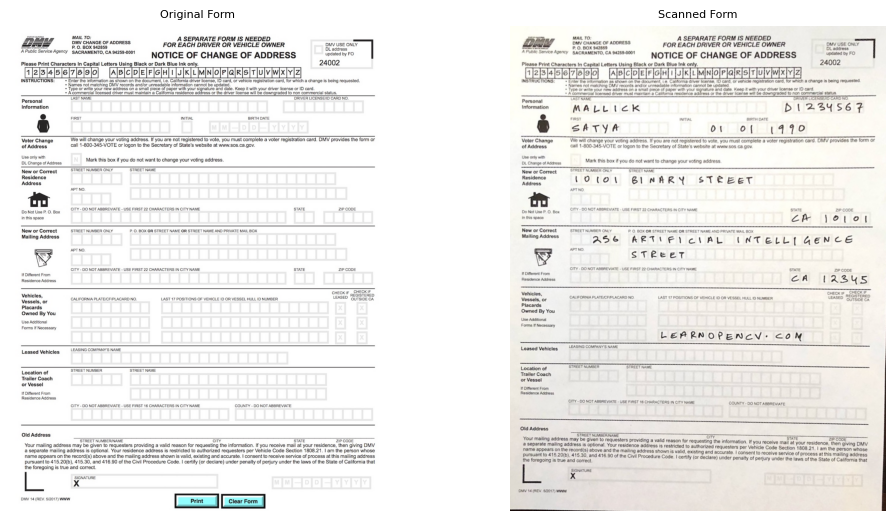

True

In [11]:
# Use homography to warp image
height, width, channels = im1.shape
im2_reg = cv2.warpPerspective(im2, h, (width, height))

# Display results
images_dict = {
    "Original Form": im1,
    "Scanned Form": im2_reg,
}

display_images_from_dict(images_dict)
cv2.imwrite(os.path.join(OUTPUT_FOLDER, "alignedImage.jpg"), cv2.cvtColor(im2_reg, cv2.COLOR_BGR2RGB))


### 1. Setup and Preparation

The code begins with importing essential libraries:

* **os**: For file system operations such as directory creation and path handling.
* **cv2 (OpenCV)**: The core computer vision library used for image processing, feature detection, matching, and geometric transformations.
* **numpy**: For numerical operations, especially matrix and array handling.
* **matplotlib.pyplot**: Used to visualize images and results in a flexible plotting environment.

Next, a utility function `display_images_from_dict` is defined. This function takes a dictionary of images and their titles, and displays them in a grid using matplotlib. It automatically adjusts the layout based on the number of images and the specified number of columns. This visualization is useful for comparing different stages of the image registration pipeline side-by-side.

An output directory named `"outputImages"` is created if it doesn’t exist. This folder will be used to save intermediate and final output images for later review.

---

### 2. Reading and Preparing Input Images

Two images are read:

* `im1`: The **reference form** image, which serves as the geometric template.
* `im2`: The **scanned form** image, which needs to be aligned to the reference.

Both images are read using OpenCV's `cv2.imread`, which by default loads images in BGR color format. The images are converted to RGB using `cv2.cvtColor` for correct color display when visualized with matplotlib (which expects RGB format).

These two images are initially displayed side-by-side to provide a visual understanding of the input and the degree of misalignment or distortion present.

---

### 3. Grayscale Conversion and Feature Detection

For feature detection and matching, the images are converted to grayscale (`im1_gray` and `im2_gray`). Grayscale simplifies computation without losing structural information important for detecting keypoints.

The ORB (Oriented FAST and Rotated BRIEF) feature detector and descriptor extractor is then initialized with a maximum of 500 features. ORB is chosen because it is fast, rotation-invariant, and efficient for real-time and moderate-scale applications.

ORB works in two phases:

* **Detection**: Finds distinctive keypoints (corners, edges) in the images.
* **Description**: Computes binary descriptors for each keypoint, capturing local image patterns.

The code first detects keypoints in each image using `orb.detect()` and then computes their descriptors with `orb.compute()`. The detected keypoints are drawn onto the original images with rich keypoint visualization (showing the size and orientation of each feature), enabling inspection of the detected features.

These images with drawn keypoints are displayed side-by-side to show how ORB features are extracted in both the reference and scanned images.

---

### 4. Feature Matching

To find corresponding points between the reference and scanned images, the code uses a brute-force Hamming distance matcher, which is suitable for binary descriptors like ORB's.

* The matcher compares every descriptor in the reference image with every descriptor in the scanned image.
* Matches are ranked based on their Hamming distance — lower distances indicate more similar features.
* The matches are sorted ascendingly by distance.
* The top 10% of matches are retained as "good matches," reducing false matches and improving the robustness of the following steps.

These top matches are drawn between the two images, with lines connecting corresponding keypoints. This visual representation helps verify the quality of matches and the general correspondence between the two images.

---

### 5. Homography Estimation

With the good matches identified, the next step is to estimate the geometric transformation that aligns the scanned image onto the reference image.

* The coordinates of matched keypoints from both images are extracted into two arrays: `points1` (reference) and `points2` (scanned).
* The function `cv2.findHomography` is used with RANSAC (Random Sample Consensus), a robust method that estimates the homography matrix while rejecting outlier matches.
* The resulting homography matrix `h` describes a projective transformation that maps points from the scanned image to corresponding points in the reference image.

Homography captures complex transformations including translation, rotation, scaling, and perspective distortions, making it suitable for aligning images taken from different viewpoints or scanned with slight misalignment.

---

### 6. Warping the Scanned Image

Using the homography matrix `h`, the scanned form image is warped to align with the reference form. The warping is performed by OpenCV’s `cv2.warpPerspective` function, which applies the projective transformation to the entire scanned image.

The warped image `im2_reg` ideally matches the geometry of the reference image, enabling direct pixel-to-pixel comparison or further processing.

The original reference image and the warped scanned image are displayed side-by-side to visually assess the alignment quality.

---

### 7. Saving Output Images

Throughout the pipeline, several intermediate and final results are saved to the `outputImages` directory, including:

* The reference and scanned images with detected ORB keypoints drawn.
* The matched keypoints between the two images.
* The final aligned (warped) scanned image.

Saving these outputs is crucial for debugging, validation, and reporting purposes.


## Analyzing Results

**1. Initial Input Images (Original Form and Scanned Form)**

The first pair of images shows the original reference form on the left and the scanned form image on the right. The original form is perfectly flat, scanned or digitally rendered, and serves as the geometric template. The scanned form, on the other hand, is a real-world photo taken from an angle and shows perspective distortion, slight rotation, and uneven lighting. This mismatch highlights the need for image registration to align the scanned image properly with the reference.

---

**2. Feature Detection Visualization**

The second pair of images displays the detected ORB keypoints marked with red circles over both the original and scanned images. These circles represent the feature points that ORB has identified as distinctive and repeatable regions in both images.

* In the reference image, keypoints are densely scattered over text areas, form boxes, and other structural elements.
* In the scanned image, despite distortion and lighting variations, ORB detects a similar distribution of keypoints, showing robustness.
* The overlap of these keypoints in corresponding regions suggests a good basis for establishing matches between the two images.

This step confirms that the feature detector can find sufficient correspondences despite the scanned image’s distortions.

---

**3. Feature Matching Visualization**

The third image presents a composite view showing lines that connect matched keypoints between the original form and the scanned form (result form). Each colored line corresponds to a match between a feature in the reference image and one in the scanned image.

* The lines mostly connect structurally corresponding areas such as form labels, checkboxes, and text fields.
* This visualizes the successful matching of keypoints, which is critical for estimating the homography matrix.
* Despite perspective differences and noise, the system has found numerous reliable matches, enabling precise alignment.

This figure demonstrates the quality and distribution of the feature matches used for geometric transformation.

---

**4. Final Alignment Result**

The last pair shows the original form alongside the warped scanned form after applying the computed homography transformation.

* The warped scanned form is now geometrically aligned with the original form.
* Rectangular boxes, text lines, and labels are closely overlaid, indicating successful correction of rotation, perspective distortion, and scaling differences.
* This result proves the effectiveness of the feature-based registration pipeline in producing an accurately aligned image suitable for further analysis or automated data extraction.
